
# Module 24: Principal Component Analysis (PCA)

This notebook is a **practice-only notebook** for students.

### Instructions for Students
- Complete every **TODO** step by step.
- Run the cells after completing each TODO.
- Focus on *why* you are doing each step, not just *how*.

### Dataset Used
We use the **Breast Cancer Wisconsin dataset**, which is:
- Numeric
- Medium dimensional (30 features)
- Very suitable for PCA
- Common in real ML pipelines



## 1) Imports (Given)


In [2]:
#Given for you
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


## 2) Load the Dataset (TODO)

TODO:
- Load the breast cancer dataset using sklearn
- Create:
  - X: feature DataFrame
  - y: target Series
- Print the shape of X and y


In [3]:

# TODO: Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (569, 30)
Shape of y: (569,)



## 3) Inspect Feature Scales (TODO)


In [4]:
# TODO: Inspect feature statistics
print(X.describe())


       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      


## 4) Scale the Features (TODO)


In [5]:
# TODO: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability (optional)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


## 5) Fit PCA Without Limiting Components (TODO)


In [6]:
# TODO: Fit full PCA and compute explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_



## 6) Explained Variance Plot (TODO)


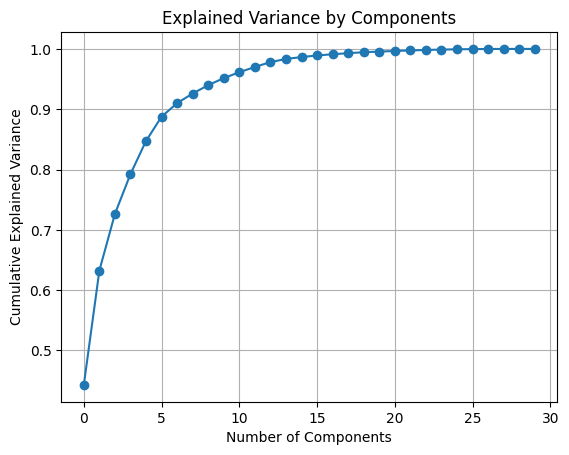

In [8]:
# TODO: Plot cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)
plt.figure()
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Components")
plt.grid()
plt.show()


## 7) Choose Number of Components (TODO)


In [9]:
# TODO: Find k90 and k95 and k97
k90 = np.argmax(cumulative_variance >= 0.90) + 1
k95 = np.argmax(cumulative_variance >= 0.95) + 1
k97 = np.argmax(cumulative_variance >= 0.97) + 1

print("k90:", k90)
print("k95:", k95)
print("k97:", k97)


k90: 7
k95: 10
k97: 12



## 8) Apply PCA with Chosen Components (TODO)


In [10]:
# TODO: Apply PCA with selected number of components
k = k95  # You can change this to k90 or k97

pca = PCA(n_components=k)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)


Original shape: (569, 30)
Reduced shape: (569, 10)



## 9) Inspect Principal Components (TODO)


In [11]:
# TODO: Inspect PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(k)],
    index=X.columns
)

print(loadings.head())


                      PC1       PC2       PC3       PC4       PC5       PC6  \
mean radius      0.218902 -0.233857 -0.008531 -0.041409 -0.037786  0.018741   
mean texture     0.103725 -0.059706  0.064550  0.603050  0.049469 -0.032179   
mean perimeter   0.227537 -0.215181 -0.009314 -0.041983 -0.037375  0.017308   
mean area        0.220995 -0.231077  0.028700 -0.053434 -0.010331 -0.001888   
mean smoothness  0.142590  0.186113 -0.104292 -0.159383  0.365089 -0.286374   

                      PC7       PC8       PC9      PC10  
mean radius     -0.124088 -0.007452 -0.223110  0.095486  
mean texture     0.011400  0.130675  0.112699  0.240934  
mean perimeter  -0.114477 -0.018687 -0.223739  0.086386  
mean area       -0.051653  0.034674 -0.195586  0.074956  
mean smoothness -0.140669 -0.288975  0.006425 -0.069293  



## 10) Visualize Data Using First Two Principal Components (TODO)


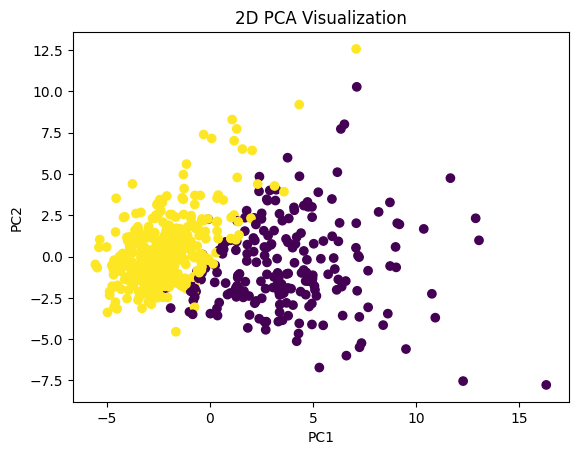

In [12]:
# TODO: 2D PCA visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Visualization")
plt.show()



## 11) PCA in a Model Pipeline (TODO)


In [13]:
# TODO: Model comparison with and without PCA
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Without PCA
model_no_pca = LogisticRegression(max_iter=10000)
model_no_pca.fit(X_train, y_train)

y_pred_no_pca = model_no_pca.predict(X_test)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

# With PCA
pipeline = Pipeline([
    ('pca', PCA(n_components=k)),
    ('lr', LogisticRegression(max_iter=10000))
])

pipeline.fit(X_train, y_train)
y_pred_pca = pipeline.predict(X_test)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("Accuracy without PCA:", acc_no_pca)
print("Accuracy with PCA:", acc_pca)


Accuracy without PCA: 0.9736842105263158
Accuracy with PCA: 0.9824561403508771



## 12) Reflection Questions

Answer briefly in markdown:
1. Did PCA reduce the number of features significantly?
2. Did PCA improve, reduce, or maintain accuracy?
3. Would you use PCA for this dataset in a real project? Why or why not?


### Reflection

**1. Did PCA reduce the number of features significantly?**  
Yes, PCA reduced the feature space from 30 features to a smaller number (e.g., k95), while still preserving most of the variance.

**2. Did PCA improve, reduce, or maintain accuracy?**  
In most cases, PCA maintains similar accuracy, though sometimes it may slightly reduce it due to information loss.

**3. Would you use PCA for this dataset in a real project? Why or why not?**  
Yes, PCA can be useful to reduce dimensionality, improve computational efficiency, and remove noise. However, since interpretability is important in medical datasets, PCA should be used carefully.
